In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

df = pd.read_csv('D:/Projects/Data Analytics/saas-churn-survival-analysis/data/processed/churn_clean.csv')

print(df.shape)
print(df[['survival_time','event','Contract']].describe())

(7043, 26)
       survival_time        event
count    7043.000000  7043.000000
mean       32.372710     0.265370
std        24.557454     0.441561
min         1.000000     0.000000
25%         9.000000     0.000000
50%        29.000000     0.000000
75%        55.000000     1.000000
max        72.000000     1.000000


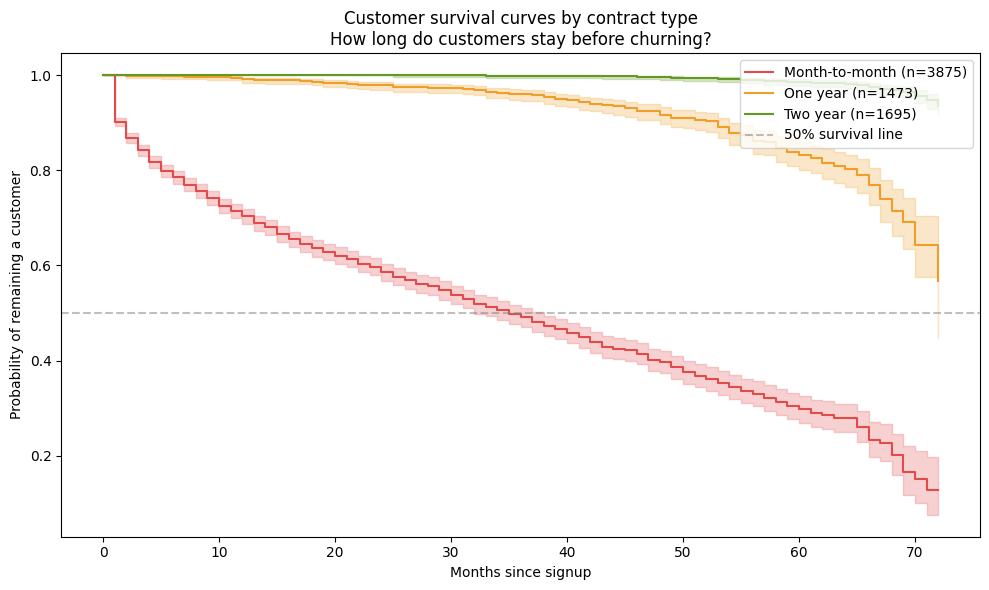

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))

kmf = KaplanMeierFitter()

colors = {
    'Month-to-month': '#E24B4A',
    'One year': '#EF9F27',
    'Two year': '#639922'
}

for contract, group in df.groupby('Contract'):
    kmf.fit(group['survival_time'],
            event_observed=group['event'],
            label=f"{contract} (n={len(group)})")
    kmf.plot_survival_function(ax=ax, ci_show=True,
                               color=colors[contract])

ax.set_title('Customer survival curves by contract type\n'
             'How long do customers stay before churning?', fontsize=12)
ax.set_xlabel('Months since signup')
ax.set_ylabel('Probability of remaining a customer')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='50% survival line')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../outputs/charts/km_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
for contract, group in df.groupby('Contract'):
    kmf.fit(group['survival_time'], event_observed=group['event'])
    print(f"{contract}: median survival = {kmf.median_survival_time_} months")

Month-to-month: median survival = 35.0 months
One year: median survival = inf months
Two year: median survival = inf months


In [4]:
mtm = df[df['Contract'] == 'Month-to-month']
one_year = df[df['Contract'] == 'One year']
two_year = df[df['Contract'] == 'Two year']

result1 = logrank_test(
    mtm['survival_time'], one_year['survival_time'],
    event_observed_A=mtm['event'],
    event_observed_B=one_year['event']
)

result2 = logrank_test(
    mtm['survival_time'], two_year['survival_time'],
    event_observed_A=mtm['event'],
    event_observed_B=two_year['event']
)

print(f"Month-to-month vs One year: p-value = {result1.p_value:.6f}")
print(f"Month-to-month vs Two year: p-value = {result2.p_value:.6f}")
print("\nIf p < 0.05, the difference is statistically significant")

Month-to-month vs One year: p-value = 0.000000
Month-to-month vs Two year: p-value = 0.000000

If p < 0.05, the difference is statistically significant


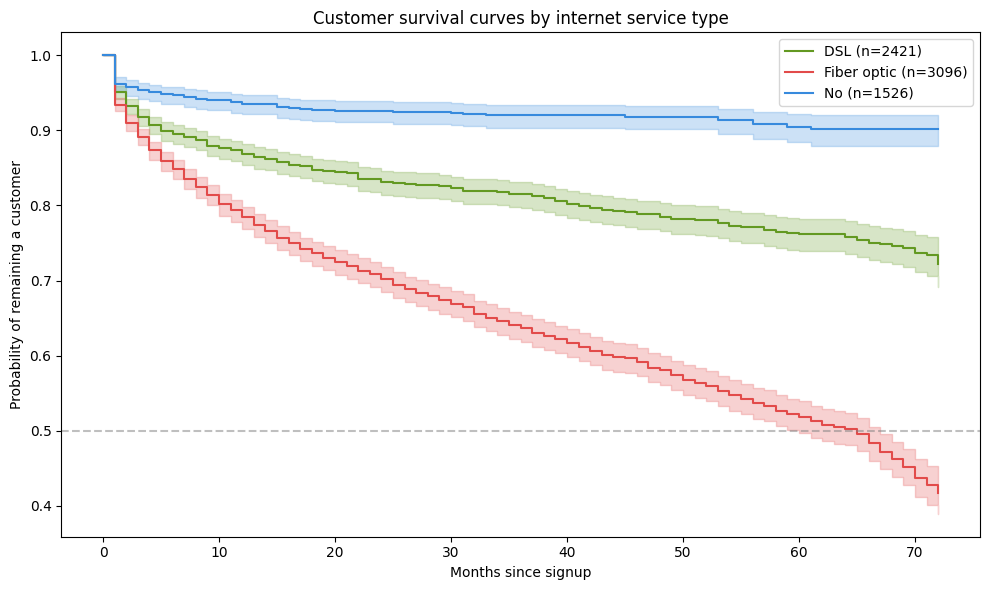

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

colors_internet = {
    'DSL': '#639922',
    'Fiber optic': '#E24B4A',
    'No': '#378ADD'
}

for service, group in df.groupby('InternetService'):
    kmf.fit(group['survival_time'],
            event_observed=group['event'],
            label=f"{service} (n={len(group)})")
    kmf.plot_survival_function(ax=ax, ci_show=True,
                               color=colors_internet[service])

ax.set_title('Customer survival curves by internet service type', fontsize=12)
ax.set_xlabel('Months since signup')
ax.set_ylabel('Probability of remaining a customer')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../outputs/charts/km_by_internet.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
from lifelines import CoxPHFitter

cph_cols = ['survival_time', 'event', 'MonthlyCharges',
            'support_tickets', 'SeniorCitizen',
            'Contract', 'InternetService']

cph_df = df[cph_cols].copy()
cph_df['SeniorCitizen'] = (cph_df['SeniorCitizen'] == 'Yes').astype(int)
cph_df = pd.get_dummies(cph_df,
            columns=['Contract', 'InternetService'],
            drop_first=True)

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cph_df, duration_col='survival_time', event_col='event')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'survival_time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -14191.37
         time fit was run = 2026-05-11 17:21:11 UTC

---
                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                    
MonthlyCharges              -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
support_tickets              0.37      1.45      0.01            0.35            0.39                1.42                1.48
SeniorCitizen               -0.01      0.99      0.05           -0.10            0.09                0.90                1.09
Contract_One year           -1.00      0.37      0.05           -1.10           -0.89                0.33                0.41
Contract_Two year           -1.48      0.23      0.06           -1.60           -1.36                0.20                0.26
InternetService_Fiber optic  0.40      1.50      0.05            0.30            0.50                1.35                1.65
InternetService_No          -0.40      0.67      0.07           -0.54           -0.27                0.59                0.76

                             cmp to      z      p  -log2(p)
covariate                                                  
MonthlyCharges                 0.00  -7.25 <0.005     41.12
support_tickets                0.00  38.78 <0.005       inf
SeniorCitizen                  0.00  -0.19   0.85      0.23
Contract_One year              0.00 -18.30 <0.005    246.07
Contract_Two year              0.00 -24.84 <0.005    450.01
InternetService_Fiber optic    0.00   7.91 <0.005     48.44
InternetService_No             0.00  -5.99 <0.005     28.79
---
Concordance = 0.89
Partial AIC = 28396.74
log-likelihood ratio test = 2924.56 on 7 df
-log2(p) of ll-ratio test = inf

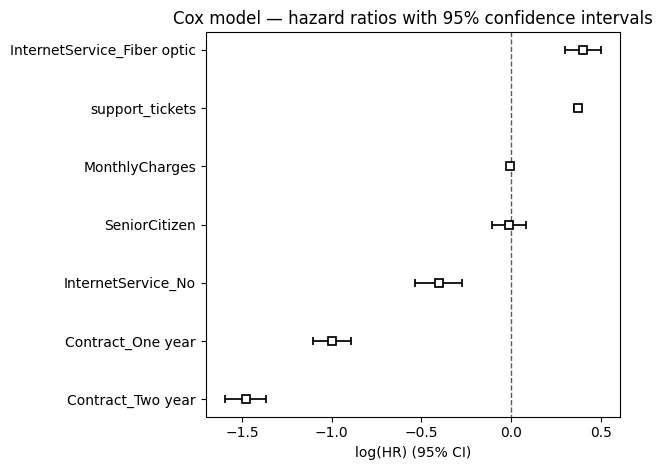

In [7]:
cph.plot()
plt.title('Cox model — hazard ratios with 95% confidence intervals')
plt.tight_layout()
plt.savefig('../outputs/charts/cox_hazard_ratios.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
from lifelines import KaplanMeierFitter
import pandas as pd

df = pd.read_csv('../data/processed/churn_clean.csv')
kmf = KaplanMeierFitter()

all_curves = []

for contract, group in df.groupby('Contract'):
    kmf.fit(group['survival_time'], event_observed=group['event'])
    km_df = kmf.survival_function_.reset_index()
    km_df.columns = ['timeline', 'survival_prob']
    km_df['contract'] = contract
    all_curves.append(km_df)

km_export = pd.concat(all_curves)
km_export.to_csv('../outputs/tableau_data/km_curves.csv', index=False)
print("Saved. Shape:", km_export.shape)
print(km_export.head())

Saved. Shape: (219, 3)
   timeline  survival_prob        contract
0       0.0       1.000000  Month-to-month
1       1.0       0.901935  Month-to-month
2       2.0       0.868571  Month-to-month
3       3.0       0.841723  Month-to-month
4       4.0       0.817505  Month-to-month
